In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install -q qiskit[visualization]
!pip install -q qiskit_aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 48.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.8 MB/s eta 0:00:00:00:01:01


In [4]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
%matplotlib inline
import math
from qiskit_aer import AerSimulator

In [5]:
def run_sim(qc):
    qc.save_statevector()
    state_sim = AerSimulator(method="statevector")
    result = state_sim.run(qc).result()
    statevec = result.get_statevector(qc)

    qc.measure_all()
    qasm_sim = AerSimulator()
    result = qasm_sim.run(qc, shots=1024).result()
    counts = result.get_counts(qc)

    return statevec, counts

In [ ]:
# how to run in the latest version of qiskit - 
# Hadamard superposition of first bit
qc = QuantumCircuit(2,2)
qc.h(0)
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

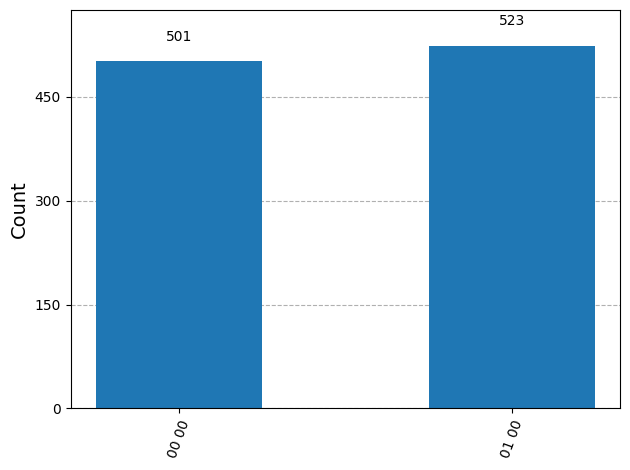

In [ ]:
plot_histogram(counts)

In [ ]:
# H + CNOT = entanglement = |00> and |11>
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

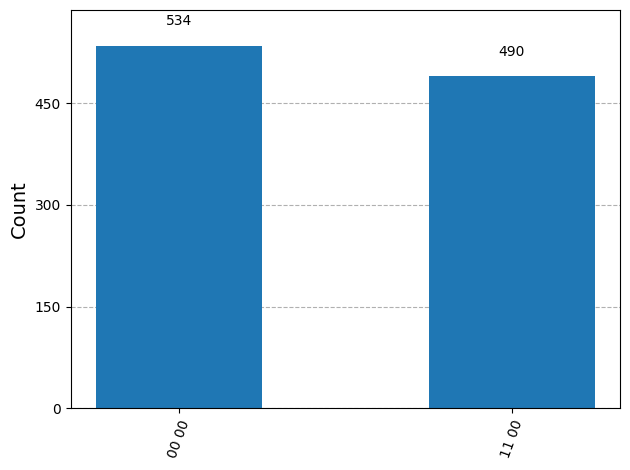

In [9]:
plot_histogram(counts)

In [ ]:
qc = QuantumCircuit(2,2)
qc.rx(math.pi/4, 0) # keeping x as basis rotate along y
qc.rx(math.pi/2, 1)
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

In [ ]:
qc = QuantumCircuit(2,2)
qc.ry(math.pi/4, 0) # keeping y as basis rotate along x
qc.ry(math.pi/2, 1) # this is same as Hadamard gate
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

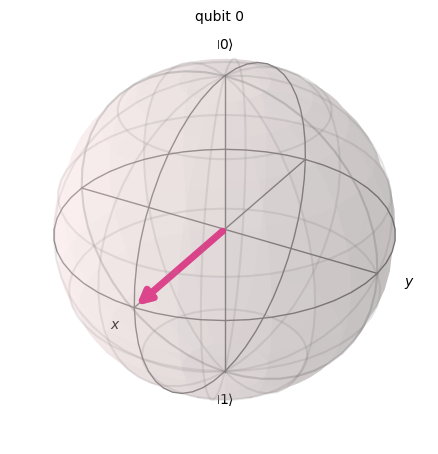

In [ ]:
qc = QuantumCircuit(1,1)
qc.h(0) # same as qubit 1
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

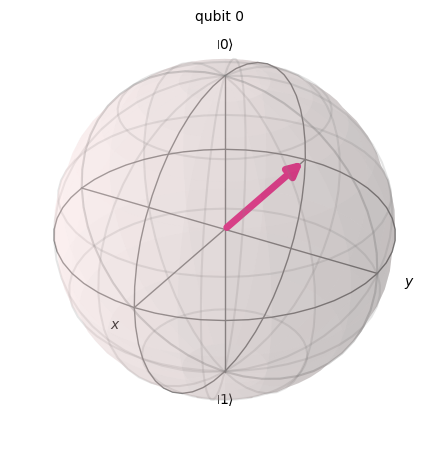

In [13]:
qc = QuantumCircuit(1,1)
qc.h(0)
qc.z(0)
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)

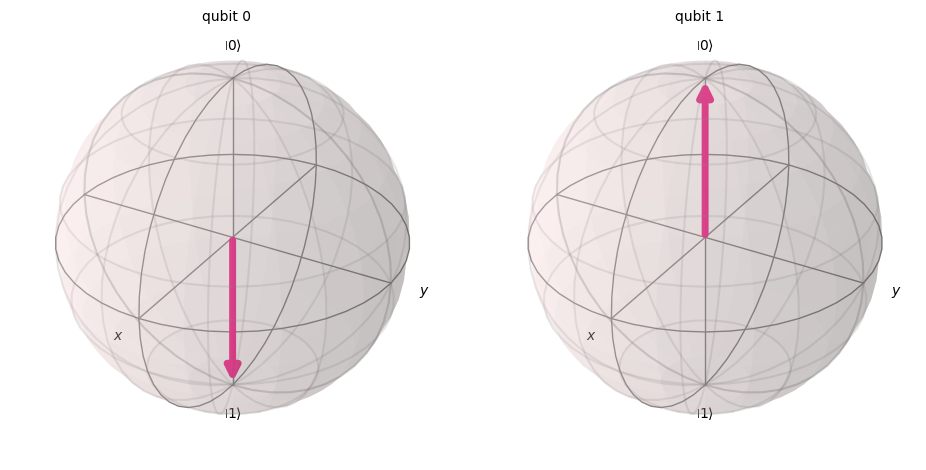

In [14]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0, 1)
qc.z(0)
qc.cx(0,1)
qc.h(0)
statevec, counts = run_sim(qc)
plot_bloch_multivector(statevec)